# 04. Baseline Model

## Цель
Обучить baseline-модель классификации бухгалтерских документов на заранее подготовленных признаках и оценить качество модели на тестовой выборке.

## Задачи
1. Загрузить матрицы признаков и целевую переменную из этапа preprocessing.
2. Обучить baseline-модель `LogisticRegression`.
3. Получить предсказания на test-выборке.
4. Посчитать ключевые метрики качества.
5. Построить confusion matrix.
6. Проанализировать типичные ошибки модели.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.svm import LinearSVC
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 200)

In [2]:
X_train_processed = sparse.load_npz("../data/modified/X_train_processed.npz")
X_test_processed = sparse.load_npz("../data/modified/X_test_processed.npz")
y_train = pd.read_csv("../data/modified/y_train.csv").squeeze("columns")
y_test = pd.read_csv("../data/modified/y_test.csv").squeeze("columns")

In [3]:
shape_summary = pd.DataFrame({
    "matrix": ["X_train_processed", "X_test_processed", "y_train", "y_test"],
    "rows": [
        X_train_processed.shape[0],
        X_test_processed.shape[0],
        len(y_train),
        len(y_test)
    ],
    "cols_or_unique_classes": [
        X_train_processed.shape[1],
        X_test_processed.shape[1],
        y_train.nunique(),
        y_test.nunique()
    ]
})
display(shape_summary)

,matrix,rows,cols_or_unique_classes
0,X_train_processed,292,318
1,X_test_processed,51,318
2,y_train,292,27
3,y_test,51,24


In [18]:
baseline_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)
baseline_model.fit(X_train_processed, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [19]:
y_pred = baseline_model.predict(X_test_processed)

In [20]:
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")
metrics_df = pd.DataFrame({
    "metric": ["accuracy", "macro_f1", "weighted_f1"],
    "value": [accuracy, macro_f1, weighted_f1]
})
display(metrics_df)

,metric,value
0,accuracy,0.725490
1,macro_f1,0.588578
2,weighted_f1,0.675579


In [21]:
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T
display(report_df)

,precision,recall,f1-score,support
1000001,1.000000,1.000000,1.000000,6.00000
1001004,0.000000,0.000000,0.000000,2.00000
4000006,0.000000,0.000000,0.000000,2.00000
4000010,1.000000,0.500000,0.666667,6.00000
4000012,1.000000,1.000000,1.000000,3.00000
4000013,0.000000,0.000000,0.000000,0.00000
4000015,1.000000,0.500000,0.666667,2.00000
4000017,0.000000,0.000000,0.000000,1.00000
4000021,0.500000,1.000000,0.666667,1.00000
4000026,0.000000,0.000000,0.000000,3.00000


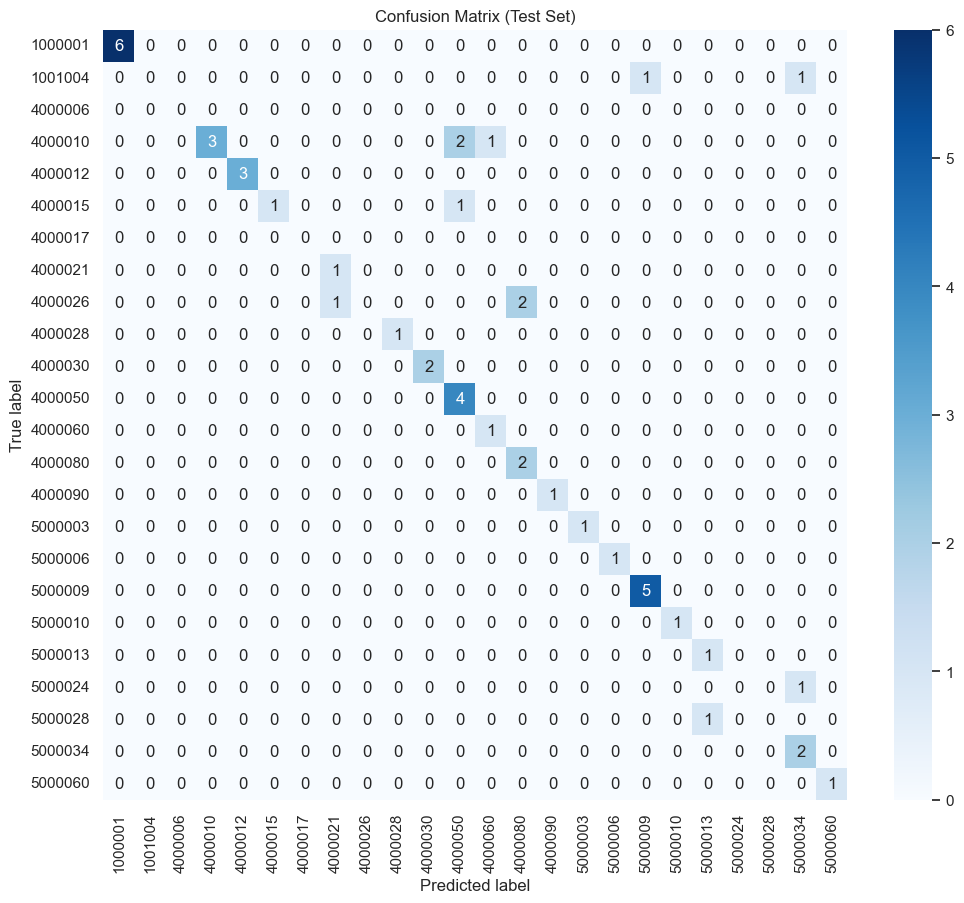

,1000001,1001004,4000006,4000010,4000012,4000015,4000017,4000021,4000026,4000028,4000030,4000050,4000060,4000080,4000090,5000003,5000006,5000009,5000010,5000013,5000024,5000028,5000034,5000060
1000001,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1001004,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
4000006,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4000010,0,0,0,3,0,0,0,0,0,0,0,2,1,0,0,0,0,0,0,0,0,0,0,0
4000012,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4000015,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
4000017,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4000021,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4000026,0,0,0,0,0,0,0,1,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0
4000028,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [22]:
labels_in_test = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels_in_test)
cm_df = pd.DataFrame(cm, index=labels_in_test, columns=labels_in_test)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

In [10]:
per_class_metrics = (
    report_df.loc[
        [idx for idx in report_df.index if str(idx).isdigit()],
        ["precision", "recall", "f1-score", "support"]
    ]
    .sort_values("f1-score", ascending=False)
)
display(per_class_metrics)

,precision,recall,f1-score,support
1000001,1.000000,1.0,1.000000,6.0
4000012,1.000000,1.0,1.000000,3.0
4000010,1.000000,1.0,1.000000,6.0
4000026,1.000000,1.0,1.000000,3.0
4000015,1.000000,1.0,1.000000,2.0
4000021,1.000000,1.0,1.000000,1.0
5000003,1.000000,1.0,1.000000,1.0
4000080,1.000000,1.0,1.000000,2.0
4000090,1.000000,1.0,1.000000,1.0
4000050,1.000000,1.0,1.000000,4.0


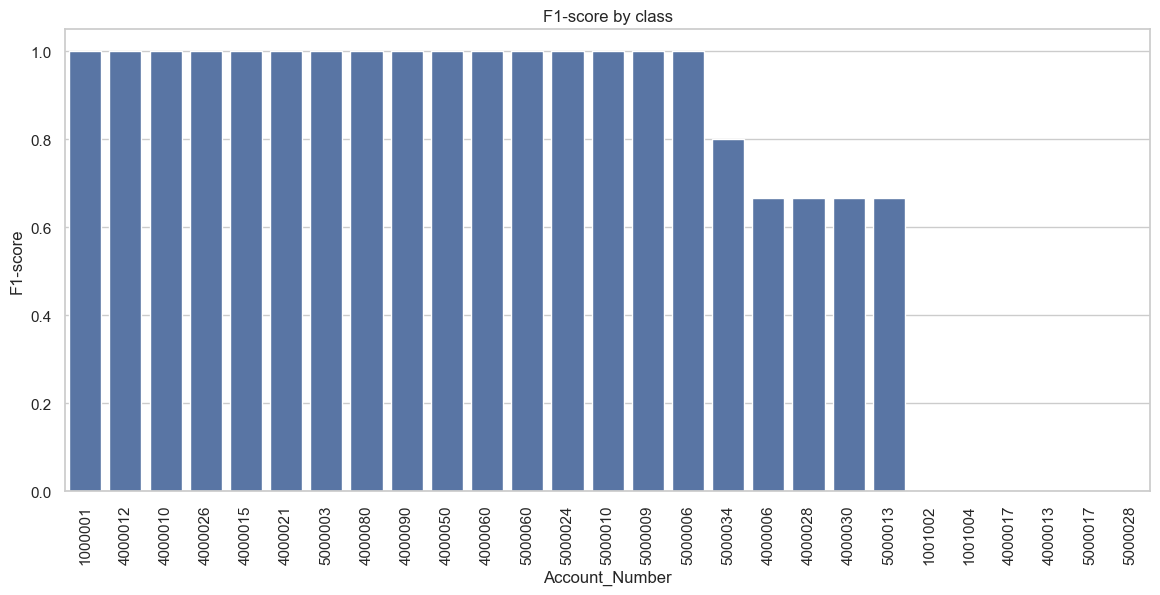

In [11]:
per_class_metrics_plot = per_class_metrics.reset_index().rename(columns={"index": "class_label"})
plt.figure(figsize=(14, 6))
sns.barplot(data=per_class_metrics_plot, x="class_label", y="f1-score")
plt.title("F1-score by class")
plt.xlabel("Account_Number")
plt.ylabel("F1-score")
plt.xticks(rotation=90)
plt.show()

In [12]:
predictions_df = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_pred
})
predictions_df["is_correct"] = (predictions_df["y_true"] == predictions_df["y_pred"]).astype(int)
display(predictions_df.head(20))

,y_true,y_pred,is_correct
0,4000010,4000010,1
1,4000010,4000010,1
2,4000080,4000080,1
3,4000012,4000012,1
4,4000012,4000012,1
5,4000012,4000012,1
6,4000010,4000010,1
7,4000015,4000015,1
8,4000015,4000015,1
9,1000001,1000001,1


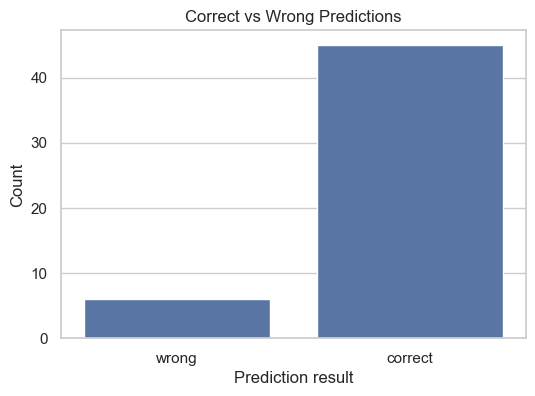

In [13]:
correctness_counts = predictions_df["is_correct"].value_counts().sort_index().reset_index()
correctness_counts.columns = ["is_correct", "count"]
correctness_counts["label"] = correctness_counts["is_correct"].map({0: "wrong", 1: "correct"})
plt.figure(figsize=(6, 4))
sns.barplot(data=correctness_counts, x="label", y="count")
plt.title("Correct vs Wrong Predictions")
plt.xlabel("Prediction result")
plt.ylabel("Count")
plt.show()

In [14]:
misclassified_df = predictions_df[predictions_df["is_correct"] == 0].copy()
display(misclassified_df.head(50))

,y_true,y_pred,is_correct
17,4000030,4000028,0
21,1001004,1001002,0
39,4000006,4000013,0
44,4000017,5000017,0
46,1001004,5000034,0
50,5000028,5000013,0


In [15]:
error_pairs = (
    misclassified_df.groupby(["y_true", "y_pred"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
display(error_pairs.head(20))

,y_true,y_pred,count
0,1001004,1001002,1
1,1001004,5000034,1
2,4000006,4000013,1
3,4000017,5000017,1
4,4000030,4000028,1
5,5000028,5000013,1


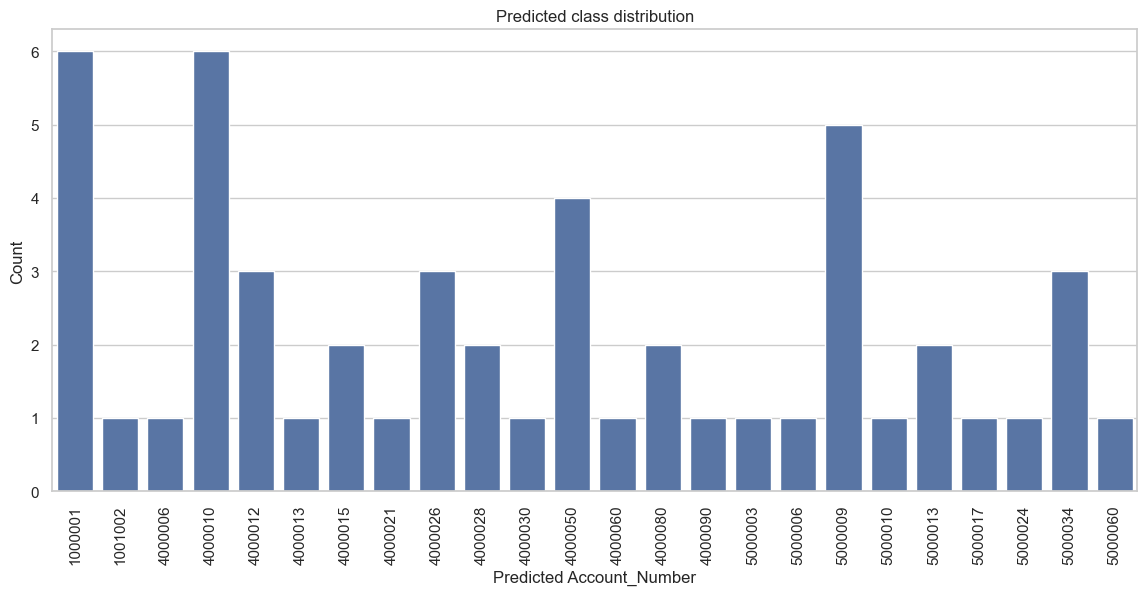

In [16]:
pred_class_counts = pd.Series(y_pred).value_counts().reset_index()
pred_class_counts.columns = ["predicted_class", "count"]
plt.figure(figsize=(14, 6))
sns.barplot(data=pred_class_counts, x="predicted_class", y="count")
plt.title("Predicted class distribution")
plt.xlabel("Predicted Account_Number")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

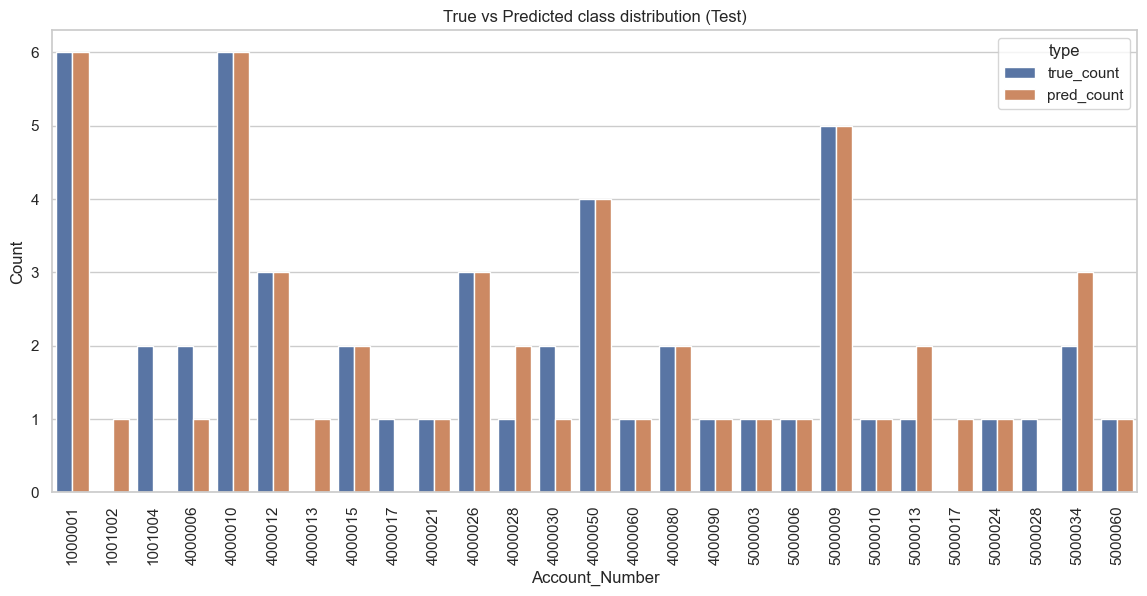

In [17]:
true_counts = y_test.value_counts().rename("true_count")
pred_counts = pd.Series(y_pred).value_counts().rename("pred_count")
distribution_compare = pd.concat([true_counts, pred_counts], axis=1).fillna(0).reset_index()
distribution_compare.columns = ["Account_Number", "true_count", "pred_count"]
distribution_compare_long = distribution_compare.melt(
    id_vars="Account_Number",
    value_vars=["true_count", "pred_count"],
    var_name="type",
    value_name="count"
)
plt.figure(figsize=(14, 6))
sns.barplot(data=distribution_compare_long, x="Account_Number", y="count", hue="type")
plt.title("True vs Predicted class distribution (Test)")
plt.xlabel("Account_Number")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

## Итоги baseline-модели

На данном этапе была обучена baseline-модель `LogisticRegression` на признаках, подготовленных в notebook `03_preprocessing.ipynb`.

### Что было сделано
1. Были загружены готовые матрицы признаков `X_train_processed` и `X_test_processed`, а также целевая переменная `y_train` и `y_test`.
2. Модель `LogisticRegression` была обучена на training-части выборки.
3. На test-части были получены предсказания и рассчитаны ключевые метрики качества:
   - `accuracy`
   - `macro F1`
   - `weighted F1`
4. Дополнительно были построены:
   - classification report,
   - confusion matrix,
   - анализ распределения предсказанных классов,
   - таблица наиболее частых ошибок.

### Интерпретация
- `accuracy` показывает общую долю правильных предсказаний;
- `macro F1` особенно важна для данной задачи, так как классы распределены неравномерно;
- `weighted F1` дает более усредненную оценку с учетом поддержки классов.

### Следующие шаги
1. Сравнить baseline-модель с альтернативной моделью, например `LinearSVC`.
2. Проверить влияние признака `Supplier_Name`.
3. Расширить анализ ошибок на уровне исходных документов.